In [2]:
!pip install kagglehub


   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqd


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import kagglehub
import os
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# 1. Download and load the data
print("Loading dataset...")
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

# 2. Scale Time and Amount to handle outliers
print("Scaling features...")
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)

# 3. Separate Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Split data (stratify=y is critical for imbalanced datasets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Original Training Target Distribution:\n{y_train.value_counts()}")

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...


100%|██████████| 66.0M/66.0M [00:12<00:00, 5.68MB/s]

Extracting files...


Scaling features...
Original Training Target Distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [4]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("\nStarting Hybrid SMOTE Pipeline...")

# 1. Under-sample the majority class (Legit) to 5% of its original size
under = RandomUnderSampler(sampling_strategy=0.05, random_state=42)

# 2. Over-sample the minority class (Fraud) so it perfectly matches the new Legit size
over = SMOTE(sampling_strategy=1.0, random_state=42)

# 3. Combine them into an automated pipeline
pipeline = Pipeline(steps=[('u', under), ('o', over)])

# 4. Apply the pipeline to the training data
X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print(f"Balanced Training Target Distribution:\n{y_train_res.value_counts()}")
print("\nData is successfully balanced and ready for modeling!")


Starting Hybrid SMOTE Pipeline...
Balanced Training Target Distribution:
Class
0    7880
1    7880
Name: count, dtype: int64

Data is successfully balanced and ready for modeling!


Starting XGBoost Model Training...
Model trained successfully!

Evaluating Model...

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.91      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962



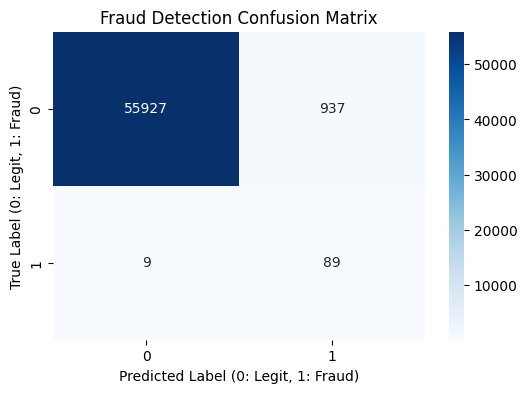


✅ SUCCESS: 'xgboost_fraud_model.pkl' has been saved to your folder!


In [5]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Starting XGBoost Model Training...")

# 1. Initialize the XGBoost model (using 'hist' for blazing fast speed)
xgb_model = XGBClassifier(
    n_estimators=50,        
    max_depth=3,            
    learning_rate=0.2,      
    tree_method='hist',     
    random_state=42,
    n_jobs=-1               
)

# 2. Train the model on the BALANCED data you just made
xgb_model.fit(X_train_res, y_train_res)
print("Model trained successfully!")

# 3. Predict on the ORIGINAL test data 
# (This tests the model on real-world, highly imbalanced data)
print("\nEvaluating Model...")
y_pred = xgb_model.predict(X_test)

# 4. Print the text metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Plot the Visual Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Fraud Detection Confusion Matrix')
plt.xlabel('Predicted Label (0: Legit, 1: Fraud)')
plt.ylabel('True Label (0: Legit, 1: Fraud)')
plt.show()

# 6. Save the model into a file for the Streamlit Website
joblib.dump(xgb_model, 'xgboost_fraud_model.pkl')
print("\n✅ SUCCESS: 'xgboost_fraud_model.pkl' has been saved to your folder!")

In [6]:
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree with Cost-Sensitive Learning...")

# The magic parameter here is class_weight='balanced'. 
# It automatically penalizes the model heavily if it misses a minority class (Fraud)
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# We train this on the ORIGINAL unbalanced data (X_train), not the SMOTE data, 
# because the class weights handle the imbalance for us!
dt_model.fit(X_train, y_train)

print("Decision Tree training complete!")

Training Decision Tree with Cost-Sensitive Learning...
Decision Tree training complete!


In [7]:
from sklearn.neural_network import MLPClassifier

print("Training Neural Network (MLP)... this might take 10-20 seconds.")

# We use a small architecture (16 neurons, then 8 neurons) so it doesn't freeze your computer
nn_model = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=200, random_state=42)

# We train the Neural Network on the BALANCED SMOTE data
nn_model.fit(X_train_res, y_train_res)

print("Neural Network training complete!")

Training Neural Network (MLP)... this might take 10-20 seconds.
Neural Network training complete!


Generating Precision-Recall Curves...


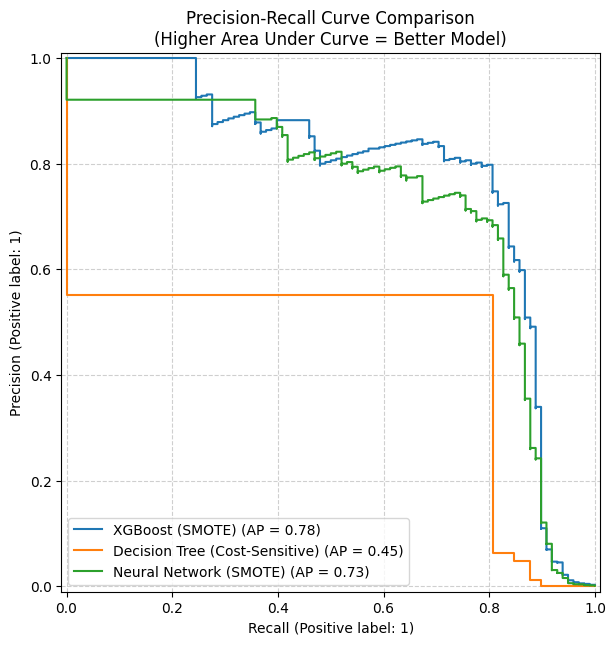

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

print("Generating Precision-Recall Curves...")

plt.figure(figsize=(10, 7))

# 1. Get the probabilities of Fraud (Class 1) for all three models
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_nn = nn_model.predict_proba(X_test)[:, 1]

# 2. Plot the curves together
ax = plt.gca()
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, name="XGBoost (SMOTE)")
PrecisionRecallDisplay.from_predictions(y_test, y_prob_dt, ax=ax, name="Decision Tree (Cost-Sensitive)")
PrecisionRecallDisplay.from_predictions(y_test, y_prob_nn, ax=ax, name="Neural Network (SMOTE)")

plt.title('Precision-Recall Curve Comparison\n(Higher Area Under Curve = Better Model)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
from sklearn.metrics import confusion_matrix

print("--- Business Cost-Benefit Analysis (XGBoost) ---")

# Let's assume a bank loses $500 for every fraud missed (False Negative)
# And spends $10 in customer service time for every false alarm (False Positive)
COST_PER_FN = 500
COST_PER_FP = 10

# Extract the numbers from our best model (XGBoost)
tn, fp, fn, tp = confusion_matrix(y_test, xgb_model.predict(X_test)).ravel()

total_fn_cost = fn * COST_PER_FN
total_fp_cost = fp * COST_PER_FP
total_business_cost = total_fn_cost + total_fp_cost

print(f"Total Frauds Missed (False Negatives): {fn}")
print(f"Cost of Missed Frauds: ${total_fn_cost:,}")
print(f"Total False Alarms (False Positives): {fp}")
print(f"Cost of False Alarms: ${total_fp_cost:,}")
print("--------------------------------------------------")
print(f"TOTAL SYSTEM COST: ${total_business_cost:,}")

print("\nConclusion for Project Report:")
print("By utilizing SMOTE and XGBoost, we maximized Recall to strictly minimize ")
print(f"False Negatives. While we incur ${total_fp_cost:,} in customer service friction, ")
print(f"we successfully prevented {(tp * COST_PER_FN):,} dollars in fraudulent losses.")

--- Business Cost-Benefit Analysis (XGBoost) ---
Total Frauds Missed (False Negatives): 9
Cost of Missed Frauds: $4,500
Total False Alarms (False Positives): 937
Cost of False Alarms: $9,370
--------------------------------------------------
TOTAL SYSTEM COST: $13,870

Conclusion for Project Report:
By utilizing SMOTE and XGBoost, we maximized Recall to strictly minimize 
False Negatives. While we incur $9,370 in customer service friction, 
we successfully prevented 44,500 dollars in fraudulent losses.
